Loaded: Walmart DataSet.csv rows: 6435

Sample raw Date values:
['05-02-2010', '12-02-2010', '19-02-2010', '26-02-2010', '05-03-2010', '12-03-2010', '19-03-2010', '26-03-2010', '02-04-2010', '09-04-2010']

Parsed 6435/6435 Date values successfully.

Data types after cleaning:
Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

HEAD:
                                0                    1                    2  \
Store                           1                   10                   37   
Date          2010-02-05 00:00:00  2010-02-05 00:00:00  2010-02-05 00:00:00   
Weekly_Sales            1643690.9           2193048.75            536006.73   
Holiday_Flag                    0                    0                    0   
Temperature                 42.31                54.34     

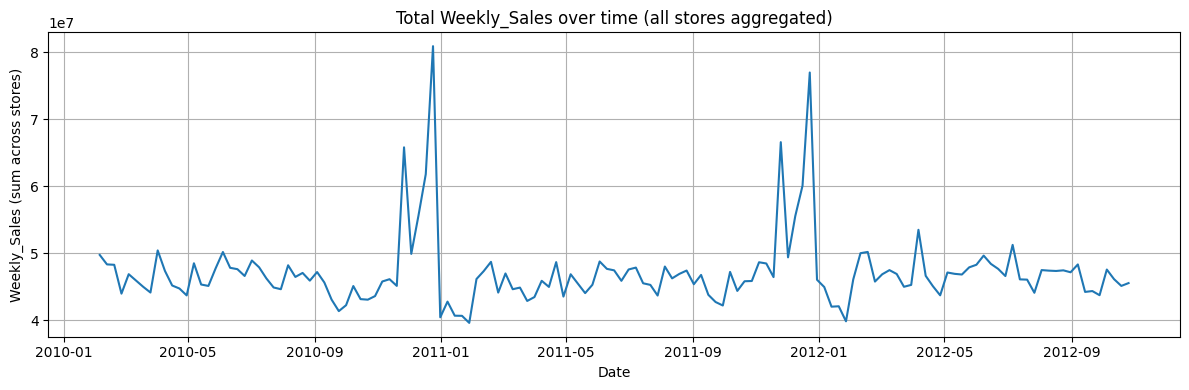

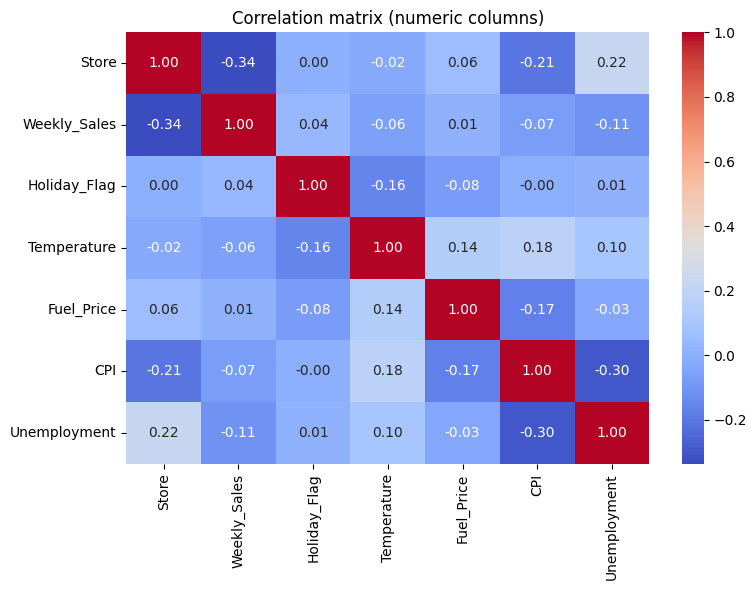


Dropped 540 rows due to lag/rolling NaNs (per-store). Remaining rows: 5895

 Using features: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'DayOfWeek', 'IsWeekend', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_mean_12']

Time-based split: train rows = 5355, test rows = 540. Cutoff date: 2012-08-03

===== MODEL PERFORMANCE (Linear Regression) =====
RMSE: 80644.83
MAE : 65063.91
R2  : 0.9765
Test rows used: 540

Sample predictions (first 10 rows):
      Date  Store     Actual    Predicted
2012-08-10      1 1592409.97 1.586124e+06
2012-08-17      1 1597868.05 1.591477e+06
2012-08-24      1 1494122.38 1.565982e+06
2012-08-31      1 1582083.40 1.564563e+06
2012-09-07      1 1661767.33 1.617348e+06
2012-09-14      1 1517428.87 1.644716e+06
2012-09-21      1 1506126.06 1.584248e+06
2012-09-28      1 1437059.26 1.561833e+06
2012-10-05      1 1670785.97 1.596910e+06
2012-10-12      1 1573072.81 1.622166e+06


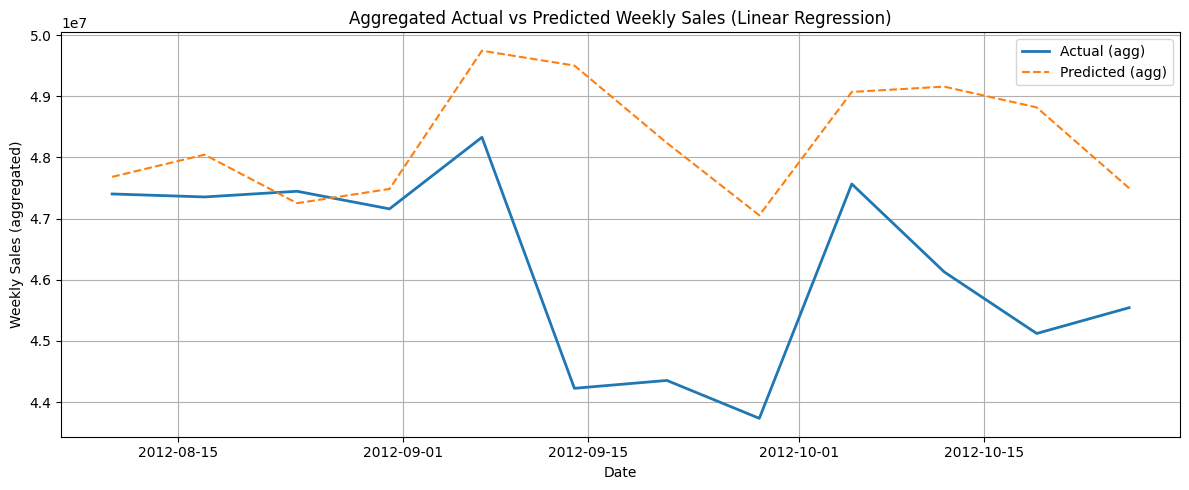


Top coefficients (by absolute value):
        feature   coefficient    abs_coeff
     Fuel_Price  5.397891e+04 5.397891e+04
          Month  5.228519e+04 5.228519e+04
           Year -1.623360e+04 1.623360e+04
           Week -8.540940e+03 8.540940e+03
   Holiday_Flag  6.469458e+03 6.469458e+03
   Unemployment -1.628671e+03 1.628671e+03
    Temperature -4.168089e+02 4.168089e+02
          Store -1.536401e+02 1.536401e+02
            CPI  1.406346e+02 1.406346e+02
rolling_mean_12  4.544883e-01 4.544883e-01
          lag_1  3.183420e-01 3.183420e-01
          lag_4  2.452546e-01 2.452546e-01
 rolling_mean_4 -1.993134e-01 1.993134e-01
          lag_2  1.692022e-01 1.692022e-01
      DayOfWeek -1.728040e-11 1.728040e-11
      IsWeekend -1.568878e-11 1.568878e-11

Saved model to linear_regression_walmart_lr.joblib and X_train sample CSV.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

fn = "Walmart DataSet.csv"
df = pd.read_csv(fn)
print("Loaded:", fn, "rows:", len(df))

print("\nSample raw Date values:")
print(df['Date'].astype(str).head(10).to_list())

df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
n_parsed = df['Date'].notna().sum()
n_total = len(df)
print(f"\nParsed {n_parsed}/{n_total} Date values successfully.")

if n_parsed < n_total * 0.98:
    formats = ["%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y", "%d/%m/%Y", "%Y/%m/%d"]
    for fmt in formats:
        mask = df['Date'].isna() & df['Date'].astype(str).notna()
        if mask.any():
            parsed = pd.to_datetime(df.loc[mask, 'Date'].astype(str), format=fmt, errors='coerce')
            df.loc[mask, 'Date'] = parsed
            print(f"Attempted format {fmt}, parsed now: {df['Date'].notna().sum()}/{n_total}")

before_drop = len(df)
df = df.dropna(subset=['Date'])
after_drop = len(df)
if after_drop < before_drop:
    print(f"Dropped {before_drop - after_drop} rows with unparseable Date values.")

df = df.sort_values('Date').reset_index(drop=True)
numeric_cols = ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("\nData types after cleaning:")
print(df.dtypes)

print("\nHEAD:")
print(df.head(8).T)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nBasic stats for numeric columns:")
print(df.select_dtypes(include=[np.number]).describe().T)

if 'Weekly_Sales' in df.columns:
    total_ts = df.groupby('Date')['Weekly_Sales'].sum()
    plt.figure(figsize=(12,4))
    plt.plot(total_ts.index, total_ts.values)
    plt.title("Total Weekly_Sales over time (all stores aggregated)")
    plt.xlabel("Date")
    plt.ylabel("Weekly_Sales (sum across stores)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation matrix (numeric columns)")
    plt.tight_layout()
    plt.show()

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek

df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

if 'Holiday_Flag' not in df.columns:
    df['Holiday_Flag'] = 0
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
lag_weeks = [1, 2, 4]
rolling_windows = [4, 12]

for lag in lag_weeks:
    df[f'lag_{lag}'] = df.groupby('Store')['Weekly_Sales'].shift(lag)

for w in rolling_windows:
    df[f'rolling_mean_{w}'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(window=w).mean().reset_index(level=0, drop=True)


before_drop2 = len(df)
required_cols_for_drop = [f'lag_{lag_weeks[0]}'] + [f'rolling_mean_{w}' for w in rolling_windows]
df = df.dropna(subset=required_cols_for_drop)
after_drop2 = len(df)
print(f"\nDropped {before_drop2 - after_drop2} rows due to lag/rolling NaNs (per-store). Remaining rows: {after_drop2}")


features = []
base_cols = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for c in base_cols:
    if c in df.columns:
        features.append(c)

features += ['Year', 'Month', 'Week', 'DayOfWeek', 'IsWeekend']
for lag in lag_weeks:
    features.append(f'lag_{lag}')
for w in rolling_windows:
    features.append(f'rolling_mean_{w}')

features = [f for f in features if f in df.columns]
print("\n Using features:", features)

X = df[features]
y = df['Weekly_Sales']

X = X.fillna(X.median())

holdout_weeks = 12
last_date = df['Date'].max()
cutoff_date = last_date - pd.Timedelta(weeks=holdout_weeks)
train_mask = df['Date'] <= cutoff_date
test_mask = df['Date'] > cutoff_date

if train_mask.sum() < 50:
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    print("\nUsed 80/20 index-based split (not enough time-based train rows).")
else:
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    print(f"\nTime-based split: train rows = {len(X_train)}, test rows = {len(X_test)}. Cutoff date: {cutoff_date.date()}")

lr = LinearRegression()
lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE (Linear Regression) =====")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2  : {r2:.4f}")
print(f"Test rows used: {len(y_test)}")

cmp = pd.DataFrame({
    'Date': df.loc[y_test.index, 'Date'],
    'Store': df.loc[y_test.index, 'Store'],
    'Actual': y_test.values,
    'Predicted': y_pred
}).reset_index(drop=True)
print("\nSample predictions (first 10 rows):")
print(cmp.head(10).to_string(index=False))

agg = cmp.groupby('Date')[['Actual','Predicted']].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(agg['Date'], agg['Actual'], label='Actual (agg)', linewidth=2)
plt.plot(agg['Date'], agg['Predicted'], linestyle='--', label='Predicted (agg)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales (aggregated)')
plt.title('Aggregated Actual vs Predicted Weekly Sales (Linear Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_
})

coef_df['abs_coeff'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coeff', ascending=False).reset_index(drop=True)

print("\nTop coefficients (by absolute value):")
print(coef_df.head(20).to_string(index=False))


try:
    import joblib
    joblib.dump(lr, "linear_regression_walmart_lr.joblib")
    X_train.to_csv("walmart_X_train_sample.csv", index=False)
    print("\nSaved model to linear_regression_walmart_lr.joblib and X_train sample CSV.")
except Exception as e:
    print("\nCould not save model artifacts (joblib missing or file error):", e)

